In [1]:
import random

import colour
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import nnls
from scipy.spatial import Delaunay

plt.style.use("default")

In [2]:
spectral_shape = colour.SpectralShape(380, 780, 5)
cmfs = colour.MSDS_CMFS["CIE 1931 2 Degree Standard Observer"].align(
    spectral_shape).values
xy_w = cmfs[:, :-1] / cmfs.sum(axis=1, keepdims=True)
print(cmfs.shape, xy_w.shape)

(81, 3) (81, 2)


In [3]:
def XYZ_to_xy(XYZ):
    if XYZ.ndim == 1:
        xy = XYZ[:2] / XYZ.sum()
        return xy

    xy = XYZ[:, :2] / XYZ.sum(axis=1, keepdims=True)
    return xy


def xy_to_XYZ(xy, Y=1.0):
    """
    Convert xy chromaticity to XYZ tristimulus values, with custom fallback:
    If y == 0:
        X = Y_input
        Y = 0
        Z = (1 - x) / x * X    (unless x == 0 → Z = 0)
    """
    xy = np.asarray(xy, dtype=float)

    def _convert(x, y, Y_input):
        if y == 0:
            # Custom rule:
            X = Y_input
            Y_val = 0.0
            if x == 0:
                Z = 0.0  # avoid division by zero
            else:
                Z = (1 - x) / x * X
            return np.array([X, Y_val, Z], dtype=float)

        # Normal case:
        X = (x / y) * Y_input
        Z = (1 - x - y) / y * Y_input
        return np.array([X, Y_input, Z], dtype=float)

    # ----- 1D -----
    if xy.ndim == 1:
        x, y = xy
        return _convert(x, y, Y)

    # ----- 2D -----
    x = xy[:, 0]
    y = xy[:, 1]

    Y_arr = np.asarray(Y)
    if Y_arr.ndim == 0:
        Y_arr = np.full_like(x, Y_arr, dtype=float)

    XYZ = np.empty((len(x), 3), dtype=float)
    for i in range(len(x)):
        XYZ[i] = _convert(x[i], y[i], Y_arr[i])

    return XYZ


def spectrum_to_XYZ(spectrum):
    S = np.asarray(spectrum)

    if S.ndim == 1:
        return cmfs.T @ S

    return S @ cmfs


def spectrum_to_xy(spectrum):
    XYZ = spectrum_to_XYZ(spectrum)
    XYZ = np.asarray(XYZ)

    return XYZ_to_xy(XYZ)

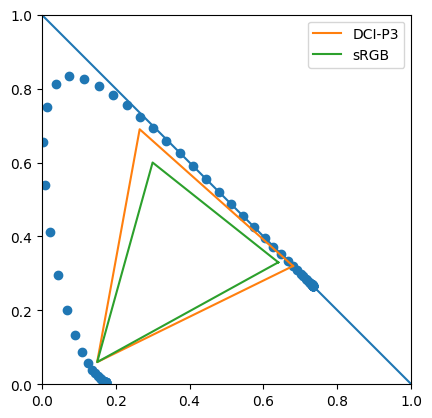

In [4]:
def plot_cie(*dots, colour_spaces=None, show_locus=True):
    if show_locus:
        plt.scatter(xy_w[:, 0], xy_w[:, 1])
    plt.axis('square')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.plot((0, 1), (1, 0))

    if colour_spaces is not None:
        if type(colour_spaces) is str:
            colour_spaces = [colour_spaces]
        for colour_space in colour_spaces:
            cs = colour.RGB_COLOURSPACES[colour_space]
            M_RGB_to_XYZ = cs.matrix_RGB_to_XYZ
            xs, ys = XYZ_to_xy(M_RGB_to_XYZ.T).T
            xs = list(xs)
            ys = list(ys)
            xs.append(xs[0])
            ys.append(ys[0])
            plt.plot(xs, ys, label=colour_space)

    for i, dot in enumerate(dots):
        dot = np.array(dot)
        if len(dot.shape) == 1:
            label = f"#{i + 1} x={dot[0]:.3f} y={dot[1]:.3f}"
        else:
            label = f"#{i + 1}"
            if dot.shape[0] != 2:
                dot = dot.T
        plt.scatter(dot[0], dot[1], label=label)

    if dots or colour_spaces:
        plt.legend()

    plt.show()


plot_cie(colour_spaces=["DCI-P3", "sRGB"])

In [5]:
def spectrum_to_Y(spectrum):
    S = np.asarray(spectrum)

    if S.ndim == 1:
        return cmfs[:, 1].T @ S

    return S @ cmfs[:, 1]

In [6]:
def plot_spectra(*spectra, norm="Y"):
    wl = np.arange(380, 781, 5)
    any_legend = False

    for i, spectrum in enumerate(spectra):
        S = np.asarray(spectrum)

        # single spectrum
        if S.ndim == 1:
            if norm == "max":
                Y = S.max()
            elif norm in ["lum", "luminance", "Y", "y"]:
                Y = spectrum_to_Y(S)
            else:
                Y = 1
            if Y != 0:
                x, y = spectrum_to_xy(S)
                S = S / Y
            else:
                x, y = 0, 0
            plt.plot(wl, S, label=f"#{i + 1} {x=:.3f} {y=:.3f}")
            any_legend = True

        elif S.ndim == 2:
            if norm == "max":
                Y = S.max(axis=1)
            elif norm in ["lum", "luminance", "Y", "y"]:
                Y = spectrum_to_Y(S)
            else:
                Y = None
            if Y is not None:
                Y_safe = np.where(Y == 0, 1, Y)
                S_normalized = S / Y_safe[:, None]
                plt.plot(wl, S_normalized.T)
            else:
                plt.plot(wl, S.T)


        else:
            raise ValueError("Spectrum must be shape (81,) or (n, 81)")

    if any_legend:
        plt.legend()
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized spectral power")
    plt.show()


In [7]:
D65 = colour.SDS_ILLUMINANTS["D65"].align(spectral_shape).values
D55 = colour.SDS_ILLUMINANTS["D55"].align(spectral_shape).values
A = colour.SDS_ILLUMINANTS["A"].align(spectral_shape).values
E = np.ones(len(xy_w))
blackbody = colour.sd_blackbody(6500, spectral_shape).values


def sds_illum(name):
    try:
        return colour.SDS_ILLUMINANTS[name].align(spectral_shape).values
    except KeyError:
        return colour.SDS_LIGHT_SOURCES[name].align(spectral_shape).values

# Solver method

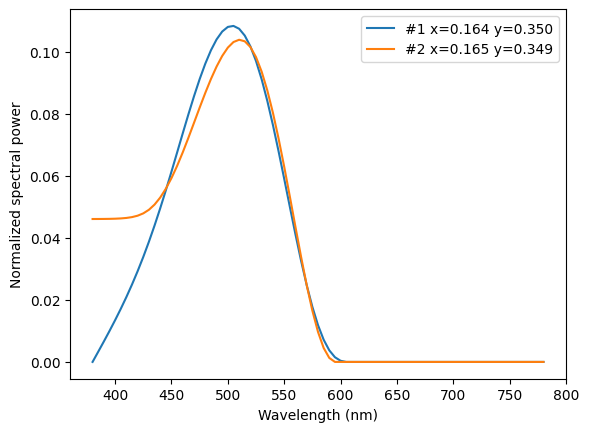

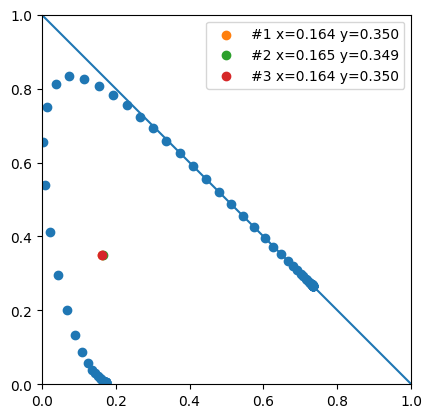

In [8]:
def xy_to_spectrum_nnls(xy, cmfs=cmfs, l1=0.05, l2=1.0):
    x, y = xy
    if not y:
        y = 1E-16

    X = (x / y)
    Z = (1 - x - y) / y
    XYZ = np.array([X, 1, Z])

    A = cmfs.T  # (3×N)
    N = A.shape[1]

    # first derivative smoothness
    D1 = np.eye(N, k=0) - np.eye(N, k=1)
    # second derivative smoothness
    D2 = np.eye(N, k=0) - 2 * np.eye(N, k=1) + np.eye(N, k=2)

    # stack system instead of forming normal equations
    C = np.vstack([A, np.sqrt(l1) * D1, np.sqrt(l2) * D2])
    d = np.concatenate([XYZ, np.zeros(N * 2)])

    s, _ = nnls(C, d)
    return s


hull = Delaunay(xy_w)
xy = (0, 0)
while not hull.find_simplex(xy) >= 0:
    x = np.random.rand()
    y = np.random.rand()
    xy = (x, y)

# xy = spectrum_to_xy(D55)
try:
    spectrum_a = xy_to_spectrum_nnls(xy, l1=0.01)
    spectrum_b = xy_to_spectrum_nnls(xy, l1=1)
except RuntimeError:
    plot_cie(xy)
else:
    plot_spectra(spectrum_a, spectrum_b)
    plot_cie(spectrum_to_xy(spectrum_a), spectrum_to_xy(spectrum_b), xy)

In [9]:
reference_sds = colour.characterisation.read_training_data_rawtoaces_v1().align(
    spectral_shape).values.T
reference_sds = np.clip(reference_sds, 0, 1)

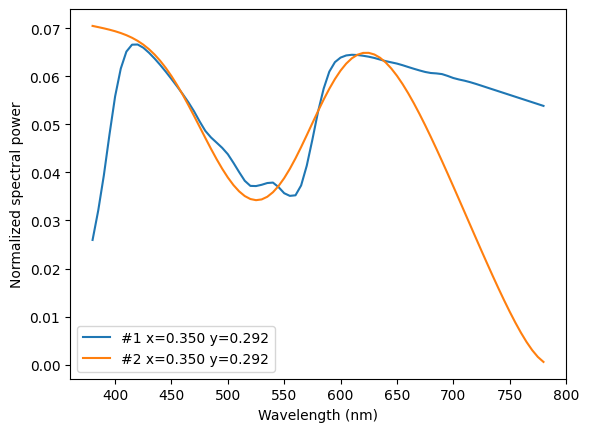

In [10]:
index = random.randint(0, len(reference_sds) - 1)

target = reference_sds[index]
target /= spectrum_to_Y(target)
xy = spectrum_to_xy(target)

reconstructed = xy_to_spectrum_nnls(xy)

plot_spectra(target, reconstructed)

# Color checker dataset

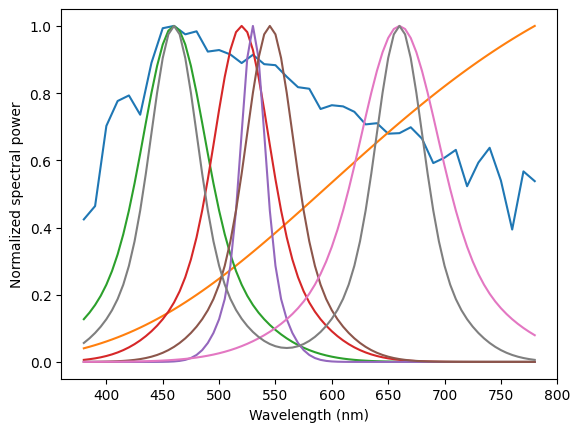

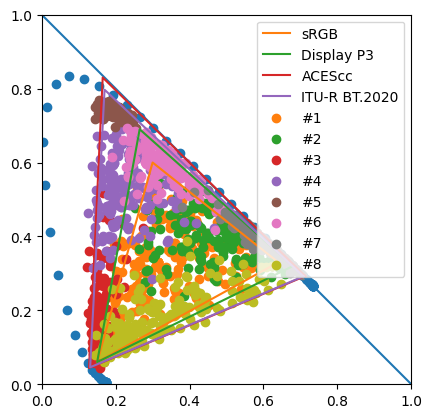

In [11]:
reference_sds = colour.characterisation.read_training_data_rawtoaces_v1().align(
    spectral_shape).values.T
reference_sds = np.clip(reference_sds, 0, 1)
illums = []
for illum_ref in ["D65", "A"]:
    illum = sds_illum(illum_ref)
    illums.append(illum)

for wavelength, width in [(460, 80), (520, 70), (530, 30), (545, 60), (660, 100)]:
    illums.append(colour.sd_single_led(wavelength, spectral_shape,
                                       half_spectral_width=width).values)

a = colour.sd_single_led(460, spectral_shape, half_spectral_width=60).values
b = colour.sd_single_led(660, spectral_shape, half_spectral_width=60).values
illums.append(a + b)

sds = []
xys = []
for illum in illums:
    sds.append(reference_sds * illum)
    xys.append(spectrum_to_xy(sds[-1]))

plot_spectra(illums, norm="max")
# plot_spectra(reference_sds, norm="none")
plot_cie(*xys, colour_spaces=["sRGB", "Display P3", "ACEScc", "ITU-R BT.2020"])

training_data_xy = np.vstack(xys)
training_data_sd = np.vstack(sds)

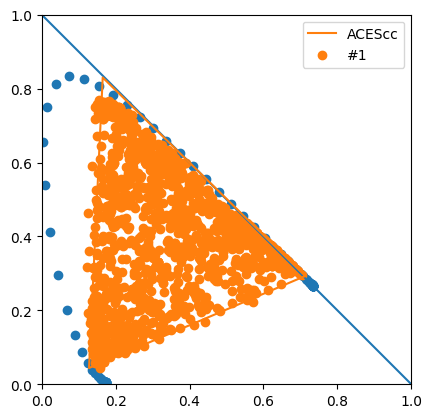

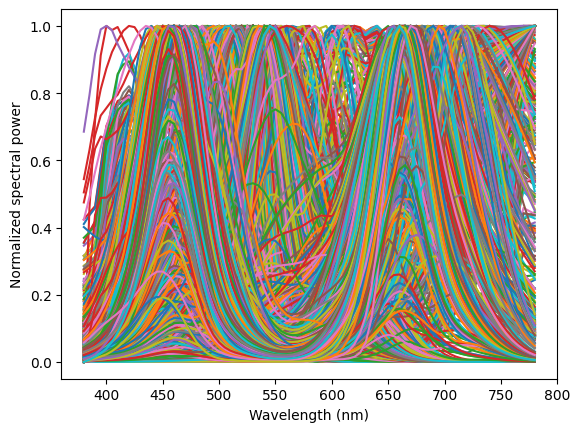

In [12]:
plot_cie(training_data_xy, colour_spaces="ACEScc")
plot_spectra(training_data_sd, norm="max")

[[ 0.25  0.5 ]
 [ 0.25  0.75]
 [ 0.5   0.5 ]]
[ 0.34752278  0.39749429] [ 0.38501862  0.53249263] [ 0.47003725  0.46498526]
[[ 0.2878795   0.5505004 ]
 [ 0.26898999  0.62658594]
 [ 0.47275495  0.51879844]]


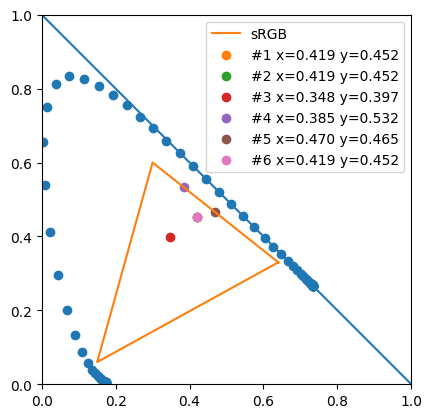

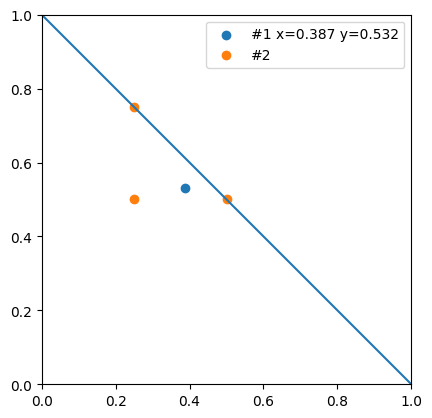

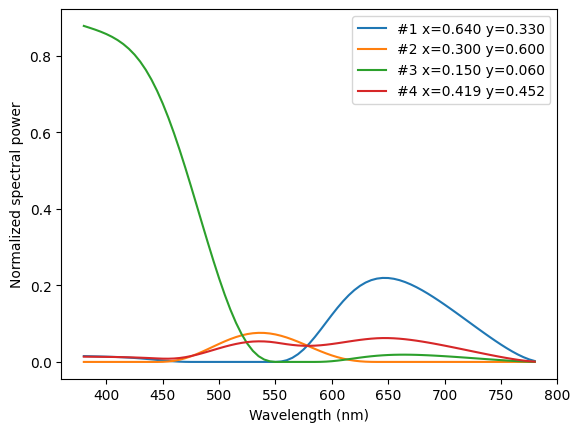

In [13]:
colour_space = "sRGB"

RGB = np.random.rand(3)
# RGB = np.array((1, 1, 0.5))
rg = XYZ_to_xy(RGB)
rgb_to_xyz = colour.RGB_COLOURSPACES[colour_space].matrix_RGB_to_XYZ.copy()

rgb_to_xyz /= rgb_to_xyz.sum(axis=0)
XYZ = rgb_to_xyz @ RGB
xy = XYZ_to_xy(XYZ)
r, g, b = XYZ_to_xy(rgb_to_xyz.T)
r_sd = xy_to_spectrum_nnls(r)
r_sd /= spectrum_to_XYZ(r_sd).sum()
g_sd = xy_to_spectrum_nnls(g)
g_sd /= spectrum_to_XYZ(g_sd).sum()
b_sd = xy_to_spectrum_nnls(b)
b_sd /= spectrum_to_XYZ(b_sd).sum()
reconstructed = r_sd * rg[0] + g_sd * rg[1] + b_sd * (1 - rg.sum())
xy_re = spectrum_to_xy(reconstructed)
step_size = 4

rg_scaled = rg * step_size
factors = rg_scaled % 1
if factors.sum() <= 1:
    area = (np.array(((0, 0), (0, 1), (1, 0))) + rg_scaled // 1) / step_size
else:
    area = (np.array(((1, 1), (0, 1), (1, 0))) + rg_scaled // 1) / step_size
print(area)
area_1 = area[0]
area_2 = area[1]
area_3 = area[2]
triangle = XYZ_to_xy(rgb_to_xyz @ xy_to_XYZ(area))
triangle_1 = XYZ_to_xy(rgb_to_xyz @ xy_to_XYZ(area_1).T)
triangle_2 = XYZ_to_xy(rgb_to_xyz @ xy_to_XYZ(area_2).T)
triangle_3 = XYZ_to_xy(rgb_to_xyz @ xy_to_XYZ(area_3).T)
print(triangle_1, triangle_2, triangle_3)
print(triangle)

plot_cie(xy, xy_re, triangle_1, triangle_2, triangle_3,
         XYZ_to_xy(rgb_to_xyz @ xy_to_XYZ(rg)), show_locus=True,
         colour_spaces=colour_space)
plot_cie(rg, area, show_locus=False)
plot_spectra(r_sd, g_sd, b_sd, reconstructed)


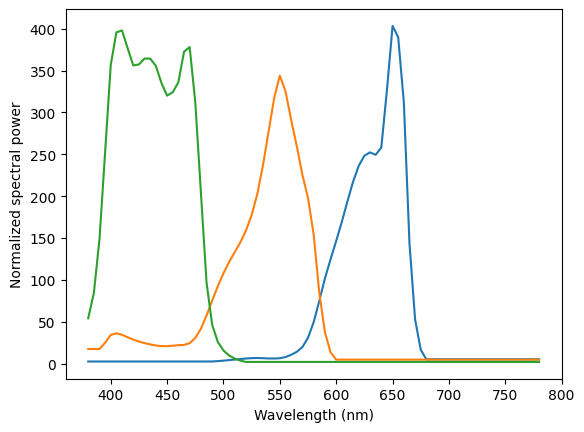

In [14]:
red_log_sensitivity = {489.8305: 0.3816, 510.5932: 0.6779, 518.6441: 0.7632,
                       525.4237: 0.8081,
                       529.6610: 0.8171, 534.7458: 0.8036, 538.9831: 0.7856,
                       544.9153: 0.7767,
                       550.4237: 0.8036, 561.0169: 1.0415, 569.4915: 1.2750,
                       577.5424: 1.5937,
                       582.2034: 1.7778, 588.9831: 1.9843, 594.4915: 2.0875,
                       603.3898: 2.2088,
                       611.8644: 2.3075, 619.4915: 2.3704, 629.6610: 2.4018,
                       634.7458: 2.3973,
                       640.6780: 2.4198, 648.3051: 2.5859, 650.4237: 2.6083,
                       655.0847: 2.5903,
                       658.8983: 2.5365, 662.2881: 2.3614, 666.9492: 1.9933,
                       676.6949: 1.0415,
                       679.6610: 0.7048}
green_log_sensitivity = {390.2542: 1.2391, 396.1864: 1.4366, 399.5763: 1.5264,
                         403.8136: 1.5578,
                         411.8644: 1.5219, 417.7966: 1.4725, 432.2034: 1.3737,
                         442.3729: 1.3244,
                         452.5424: 1.3199, 461.0169: 1.3423, 467.7966: 1.3603,
                         473.3051: 1.4456,
                         486.4407: 1.7957, 493.6441: 1.9439, 502.5424: 2.0606,
                         516.5254: 2.1728,
                         530.0847: 2.3075, 540.6780: 2.4512, 544.9153: 2.5006,
                         550.0000: 2.5365,
                         557.6271: 2.4871, 566.5254: 2.3973, 571.1864: 2.3389,
                         576.6949: 2.2716,
                         579.6610: 2.1998, 583.8983: 1.9933, 591.9492: 1.4097,
                         597.8814: 0.8530,
                         600.0000: 0.6644}
blue_log_sensitivity = {380.0847: 1.7329, 393.2203: 2.3255, 398.3051: 2.5140,
                        402.5424: 2.5859,
                        406.3559: 2.5993, 411.8644: 2.5948, 416.9492: 2.5634,
                        421.1864: 2.5499,
                        427.9661: 2.5589, 436.8644: 2.5589, 443.2203: 2.5365,
                        447.8814: 2.5095,
                        454.2373: 2.5095, 461.4407: 2.5365, 465.6780: 2.5769,
                        468.6441: 2.5859,
                        471.6102: 2.5589, 481.7797: 2.2088, 486.0169: 1.9125,
                        496.6102: 1.3378,
                        508.0508: 0.8530, 519.9153: 0.2783}
spectral_sensitivity = 10 ** np.stack([colour.SpectralDistribution(sensitivity).align(
    spectral_shape).align(spectral_shape).values for sensitivity in
                                       (red_log_sensitivity, green_log_sensitivity,
                                        blue_log_sensitivity)])
plot_spectra(spectral_sensitivity, norm=None)

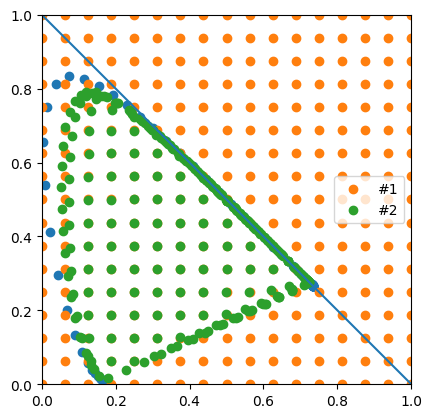

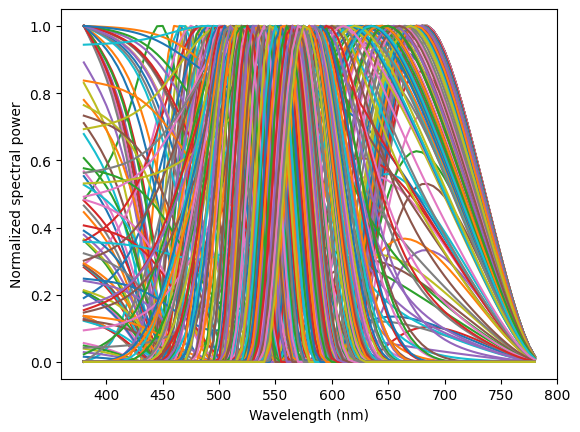

In [15]:
n = 17
x = np.linspace(0, 1, n)
xy_grid = np.stack(np.meshgrid(x, x), axis=-1).reshape(-1, 2)
# hull = Delaunay(xy_w)
# mask = hull.find_simplex(xy_grid) >= 0
# xy_grid = xy_grid[mask]
# xy_grid = xy_grid[0 < xy_grid.min(axis=1)]
spectra_grid = np.stack([xy_to_spectrum_nnls(xy) for xy in xy_grid])
xy_reconstructed = spectrum_to_xy(spectra_grid)
plot_cie(xy_grid, xy_reconstructed)
plot_spectra(spectra_grid, norm="max")

(289, 81) (3, 81) (289, 2)
(3, 289)
(289, 2)


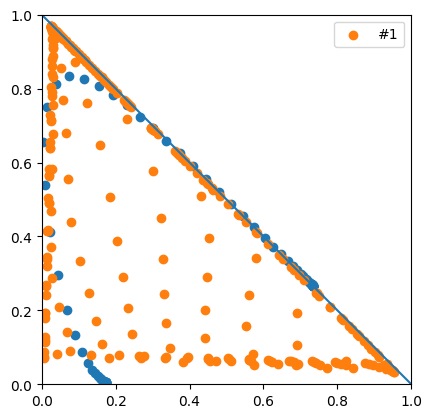

In [16]:
print(spectra_grid.shape, spectral_sensitivity.shape, xy_grid.shape)
layer_activation = spectral_sensitivity @ spectra_grid.T
print(layer_activation.shape)
layer_chroma = XYZ_to_xy(layer_activation.T)
print(layer_chroma.shape)
plot_cie(layer_chroma)

In [17]:
import math

from numba import njit, prange


@njit(parallel=True, fastmath=True)
def apply_2d_lut(image, lut):
    h, w, c = image.shape
    lut_size = lut.shape[0]

    out = np.empty((h, w, c), dtype=np.float32)

    scaling = lut_size - 1

    for y in prange(h):
        for x in prange(w):
            r = image[y, x, 0]
            g = image[y, x, 1]
            b = image[y, x, 2]

            sum = r + g + b

            if sum == 0.0:
                out[y, x, 0] = 0.0
                out[y, x, 1] = 0.0
                out[y, x, 2] = 0.0
                continue

            inv_sum = scaling / sum

            r *= inv_sum
            g *= inv_sum

            r_ind = math.floor(r)
            g_ind = math.floor(g)

            r_factor = r % 1
            g_factor = g % 1

            factor_sum = r_factor + g_factor

            r_r, r_g, r_s = lut[r_ind + 1, g_ind]
            g_r, g_g, g_s = lut[r_ind, g_ind + 1]

            if factor_sum <= 1.0:
                s_r, s_g, s_s = lut[r_ind, g_ind]
                s_factor = 1.0 - factor_sum
            else:
                s_r, s_g, s_s = lut[r_ind + 1, g_ind + 1]
                r_factor, g_factor = 1 - g_factor, 1 - r_factor
                s_factor = factor_sum - 1.0

            X0 = r_r * r_s
            Y0 = r_g * r_s
            Z0 = r_s - X0 - Y0

            X1 = g_r * g_s
            Y1 = g_g * g_s
            Z1 = g_s - X1 - Y1

            X2 = s_r * s_s
            Y2 = s_g * s_s
            Z2 = s_s - X2 - Y2

            r_out = (X0 * r_factor + X1 * g_factor + X2 * s_factor) * sum
            g_out = (Y0 * r_factor + Y1 * g_factor + Y2 * s_factor) * sum
            b_out = (Z0 * r_factor + Z1 * g_factor + Z2 * s_factor) * sum

            out[y, x, 0] = r_out
            out[y, x, 1] = g_out
            out[y, x, 2] = b_out

    return out


n = 2
image = np.random.default_rng().random(3, dtype=np.float32).reshape(1, 1, -1)
x = np.linspace(0, 1, n)
xx, yy = np.meshgrid(x, x, indexing='ij')
lut = np.stack([xx, yy, np.ones_like(xx)], axis=-1)

out_image = apply_2d_lut(image, lut)
print(lut[0, 1])
print(image)
print(out_image)

[ 0.  1.  1.]
[[[ 0.09869528  0.39925832  0.86543036]]]
[[[ 0.09869528  0.39925832  0.8654304 ]]]


In [18]:
@njit(parallel=True, fastmath=True)
def apply_2d_lut_XYZ(image, lut):
    h, w, c = image.shape
    lut_size = lut.shape[0]

    out = np.empty((h, w, c), dtype=np.float32)

    scaling = lut_size - 1

    for y in prange(h):
        for x in prange(w):
            r = image[y, x, 0]
            g = image[y, x, 1]
            b = image[y, x, 2]

            sum = r + g + b

            if sum == 0.0:
                out[y, x, 0] = 0.0
                out[y, x, 1] = 0.0
                out[y, x, 2] = 0.0
                continue

            inv_sum = scaling / sum

            r *= inv_sum
            g *= inv_sum

            r_ind = math.floor(r)
            g_ind = math.floor(g)

            r_factor = r % 1
            g_factor = g % 1

            factor_sum = r_factor + g_factor

            r_r, r_g, r_s = lut[r_ind + 1, g_ind]
            g_r, g_g, g_s = lut[r_ind, g_ind + 1]

            if factor_sum <= 1.0:
                s_r, s_g, s_s = lut[r_ind, g_ind]
                s_factor = 1.0 - factor_sum
            else:
                s_r, s_g, s_s = lut[r_ind + 1, g_ind + 1]
                r_factor, g_factor = 1 - g_factor, 1 - r_factor
                s_factor = factor_sum - 1.0

            r_out = (r_r * r_factor + g_r * g_factor + s_r * s_factor) * sum
            g_out = (r_g * r_factor + g_g * g_factor + s_g * s_factor) * sum
            b_out = (r_s * r_factor + g_s * g_factor + s_s * s_factor) * sum

            out[y, x, 0] = r_out
            out[y, x, 1] = g_out
            out[y, x, 2] = b_out

    return out

In [19]:
@njit(parallel=True)
def xys_to_XYZ(xys):
    h, w, c = xys.shape
    out = np.empty((h, w, c), dtype=np.float32)

    for j in prange(h):
        for i in prange(w):
            x = xys[j, i, 0]
            y = xys[j, i, 1]
            s = xys[j, i, 2]

            X = x * s
            Y = y * s
            Z = s - X - Y

            out[j, i, 0] = X
            out[j, i, 1] = Y
            out[j, i, 2] = Z

    return out


@njit(parallel=True)
def XYZ_to_xys(XYZ):
    h, w, c = XYZ.shape
    out = np.empty((h, w, c), dtype=np.float32)

    for j in prange(h):
        for i in prange(w):
            X = XYZ[j, i, 0]
            Y = XYZ[j, i, 1]
            Z = XYZ[j, i, 2]

            s = X + Y + Z
            x = X / s
            y = Y / s

            out[j, i, 0] = x
            out[j, i, 1] = y
            out[j, i, 2] = s

    return out


n = 2
# image = np.random.default_rng().random(3, dtype=np.float32).reshape(1, 1, -1)
x = np.linspace(0, 1, n, dtype=np.float32)
xx, yy = np.meshgrid(x, x, indexing='ij')
lut = np.stack([xx, yy, np.ones_like(xx)], axis=-1)

print(lut)
lut_XYZ = xys_to_XYZ(lut)
print(lut_XYZ)
lut_xys = XYZ_to_xys(lut_XYZ)
print(lut - lut_xys)


[[[ 0.  0.  1.]
  [ 0.  1.  1.]]

 [[ 1.  0.  1.]
  [ 1.  1.  1.]]]
[[[ 0.  0.  1.]
  [ 0.  1.  0.]]

 [[ 1.  0.  0.]
  [ 1.  1. -1.]]]
[[[ 0.  0.  0.]
  [ 0.  0.  0.]]

 [[ 0.  0.  0.]
  [ 0.  0.  0.]]]


In [20]:
rng = np.random.default_rng()

In [22]:
n = 2 ** 2
image_size = 2 ** 12
image = rng.random((image_size, image_size, 3), dtype=np.float32)
x = np.linspace(0, 1, n, dtype=np.float32)
xx, yy = np.meshgrid(x, x, indexing='ij')
lut_id = np.stack([xx, yy, np.ones_like(xx)], axis=-1)

matrix = rng.random((3, 3), dtype=np.float32)

lut_XYZ = xys_to_XYZ(lut_id)
lut_XYZ_matrix = lut_XYZ @ matrix.T
lut_matrix = XYZ_to_xys(lut_XYZ_matrix)

print("matrix")
%time image_matrix = image @ matrix.T
print("lut")
%time image_lut = apply_2d_lut(image, lut_matrix)
print("lut xyz")
%time image_lut = apply_2d_lut_XYZ(image, lut_matrix)

print("matrix")
%timeit image_matrix = image @ matrix.T
print("lut")
%timeit image_lut = apply_2d_lut(image, lut_matrix)
print("lut xyz")
%timeit image_lut = apply_2d_lut_XYZ(image, lut_matrix)

matrix
CPU times: total: 1.2 s
Wall time: 130 ms
lut
CPU times: total: 609 ms
Wall time: 163 ms
lut xyz
CPU times: total: 812 ms
Wall time: 91.4 ms
matrix
93.7 ms ± 2.82 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
lut
75.9 ms ± 3.01 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
lut xyz
73.9 ms ± 9.8 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [23]:
n = 2
image = np.zeros((1, 8, 3), dtype=np.float32)
image[0, 0, 0] = 1
image[0, 1, 0:2] = 1
image[0, 2, 1] = 1
image[0, 3, 1:3] = 1
image[0, 4, 2] = 1
image[0, 5, 0] = 1
image[0, 5, 2] = 1
image[0, 6] = 0.5
print("image")
print(image)
x = np.linspace(0, 1, n, dtype=np.float32)
xx, yy = np.meshgrid(x, x, indexing='ij')
lut_id = np.stack([xx, yy, np.ones_like(xx)], axis=-1)
print("lut_id")
print(lut_id)

matrix = rng.random((3, 3), dtype=np.float32)
print("matrix")
print(matrix)
lut_XYZ = xys_to_XYZ(lut_id)
lut_XYZ_matrix = lut_XYZ @ matrix.T
lut_matrix = XYZ_to_xys(lut_XYZ_matrix)

image_matrix = image @ matrix.T
image_lut = apply_2d_lut(image, lut_matrix)
image_lut_xyz = apply_2d_lut_XYZ(image, lut_XYZ_matrix)

print("image_matrix")
print(image_matrix)
print("image_lut")
print(image_lut)

print("image_lut_xyz")
print(image_lut_xyz)


image
[[[ 1.   0.   0. ]
  [ 1.   1.   0. ]
  [ 0.   1.   0. ]
  [ 0.   1.   1. ]
  [ 0.   0.   1. ]
  [ 1.   0.   1. ]
  [ 0.5  0.5  0.5]
  [ 0.   0.   0. ]]]
lut_id
[[[ 0.  0.  1.]
  [ 0.  1.  1.]]

 [[ 1.  0.  1.]
  [ 1.  1.  1.]]]
matrix
[[ 0.9587991   0.7524761   0.30850422]
 [ 0.9591199   0.12575406  0.6245089 ]
 [ 0.56870514  0.31275547  0.15971208]]
image_matrix
[[[ 0.9587991   0.9591199   0.56870514]
  [ 1.7112752   1.0848739   0.8814606 ]
  [ 0.7524761   0.12575406  0.31275547]
  [ 1.0609803   0.750263    0.47246754]
  [ 0.30850422  0.6245089   0.15971208]
  [ 1.2673033   1.5836289   0.7284172 ]
  [ 1.0098897   0.8546914   0.5205864 ]
  [ 0.          0.          0.        ]]]
image_lut
[[[ 0.9587991   0.9591199   0.5687052 ]
  [ 1.7112752   1.0848739   0.8814607 ]
  [ 0.7524761   0.12575406  0.31275553]
  [ 1.0609803   0.750263    0.47246766]
  [ 0.30850422  0.6245089   0.15971214]
  [ 1.2673033   1.5836289   0.72841734]
  [ 1.0098897   0.85469145  0.52058643]
  [ 0.         